## Z-table - Standard Normal Table

The Z-table (standard normal table) shows the values of the cumulative distribution function of the standard normal distribution. The Z-table maps Z-scores to the probability of a random, standard normal variable being equal or lower to this Z-score.

### Z-score

A Z-score, also known as standard score, measures how many standard deviations a data point is away from the mean of the data set. The values in the table are only valid for Z-scores from normally distributed populations.

Formula: $Z=\frac{x-\mu}{\sigma}$.

* Positive Z-score: The observation is above the mean.
* Negative Z-score: The observation is below the mean.

## Reading a Z-table

There is a positive and a negative Z-table, for positive and negative Z-scores. The indices of the Z-table represent the Z-score to the tenth's place, and the columns to the hundredth's place.

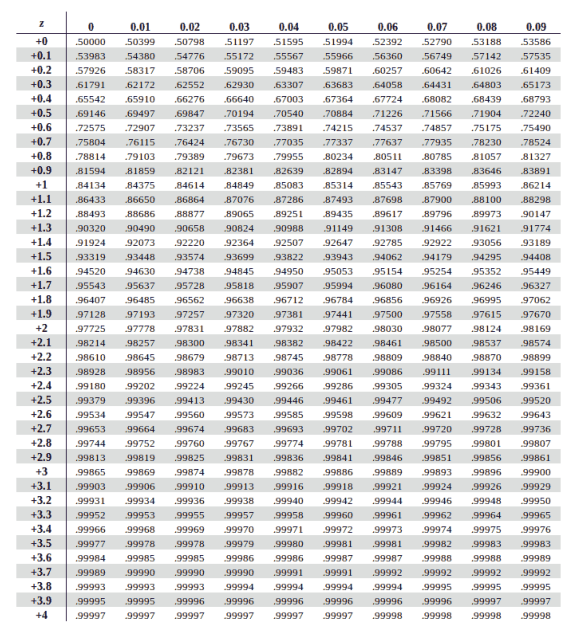

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(plt.imread("positiveztable.png"))
ax.set_axis_off()

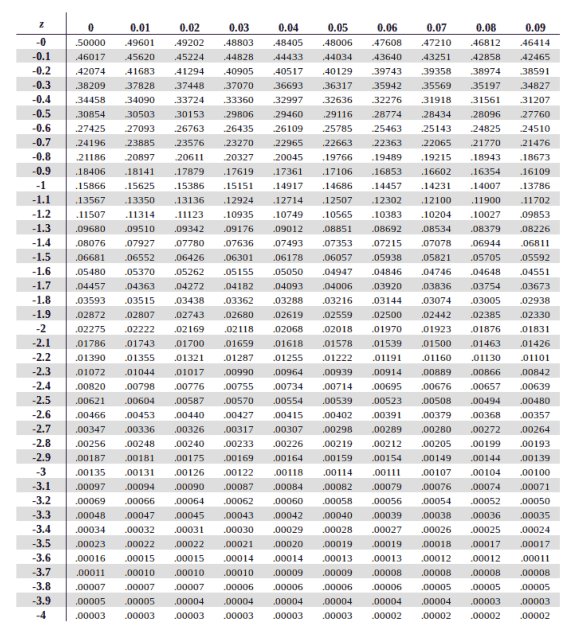

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(plt.imread("negativeztable.png"))
ax.set_axis_off()

Source: [https://www.ztable.net](https://www.ztable.net)

**For Example**: The Z-table maps a Z-score of 1 to the value ~0.8413, which means that there is a 84.13% chance that a random, standard normal variable takes on a value equal to, or lower than 1.

## Derive the Z-table

The Z-table provides the areas under the standard normal density curve from negative infinity up to certain Z-scores. These values can be obtained from the cumulative distribution function (CDF) of the standard normal distribution. The CDF of a continuous random variable is the integral of its probability density function (PDF) over a range.

* The formula for the probability density function of a normal distribution is:

    $f(x,\mu,\sigma)=\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$

* For the standard normal distribution, where the mean and variance are known to be 0 and 1 respectively, the formula can be simplified to:

    $f(x)=\frac{1}{\sqrt{2\pi}}e^{-x^2/2}$

* Integration of the PDF from negative infinity to $z$ provides the area under the curve to the left from $z$.

    $\int_{-\infty}^{z}\frac{1}{\sqrt{2\pi}}e^{-x^2/2}dx$

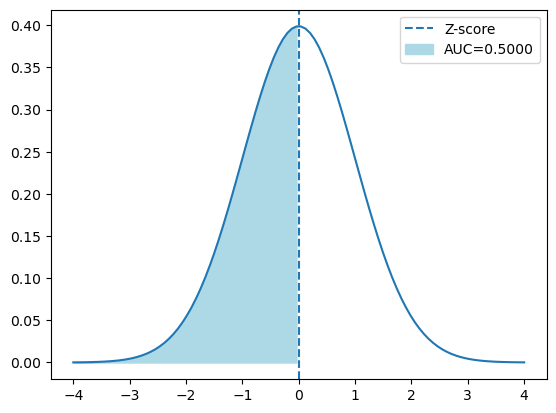

In [13]:
import numpy as np
from scipy.integrate import quad
from scipy.stats import norm

z = 0

x = np.linspace(-4, 4, 100)
y = norm.pdf(x)

auc = np.array([(x, y) for x, y in zip(x, y) if x <= z])

plt.plot(x, y)
plt.axvline(z, linestyle="dashed", label="Z-score")
plt.fill_between(auc[:,0], auc[:,1], color="lightblue", label=f"AUC={quad(norm.pdf, -np.inf, z)[0]:.4f}")
plt.legend()

### Creating a Z-table with Python

In [14]:
import pandas as pd

def z_table(negative=False):
    if negative:
        df = pd.DataFrame(data=[], index=np.negative(np.arange(0, 3.6, 0.1)),
                          columns=np.negative(np.arange(0, 0.1, 0.01)))
    else:
        df = pd.DataFrame(data=[], index=np.arange(0, 3.6, 0.1),
                          columns=np.arange(0, 0.1, 0.01))
    for idx in df.index:
        for col in df.columns:
            z = np.round(idx + col, 2)
            value,_ = quad(norm.pdf, -np.inf, z)
            df.loc[idx, col] = np.round(value, 4)
    return df

z_table()

,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09
0.0,0.5,0.504,0.508,0.512,0.516,0.5199,0.5239,0.5279,0.5319,0.5359
0.1,0.5398,0.5438,0.5478,0.5517,0.5557,0.5596,0.5636,0.5675,0.5714,0.5753
0.2,0.5793,0.5832,0.5871,0.591,0.5948,0.5987,0.6026,0.6064,0.6103,0.6141
0.3,0.6179,0.6217,0.6255,0.6293,0.6331,0.6368,0.6406,0.6443,0.648,0.6517
0.4,0.6554,0.6591,0.6628,0.6664,0.67,0.6736,0.6772,0.6808,0.6844,0.6879
0.5,0.6915,0.695,0.6985,0.7019,0.7054,0.7088,0.7123,0.7157,0.719,0.7224
0.6,0.7257,0.7291,0.7324,0.7357,0.7389,0.7422,0.7454,0.7486,0.7517,0.7549
0.7,0.758,0.7611,0.7642,0.7673,0.7704,0.7734,0.7764,0.7794,0.7823,0.7852
0.8,0.7881,0.791,0.7939,0.7967,0.7995,0.8023,0.8051,0.8078,0.8106,0.8133
0.9,0.8159,0.8186,0.8212,0.8238,0.8264,0.8289,0.8315,0.834,0.8365,0.8389


In [15]:
z_table(negative=True)

,-0.00,-0.01,-0.02,-0.03,-0.04,-0.05,-0.06,-0.07,-0.08,-0.09
-0.0,0.5,0.496,0.492,0.488,0.484,0.4801,0.4761,0.4721,0.4681,0.4641
-0.1,0.4602,0.4562,0.4522,0.4483,0.4443,0.4404,0.4364,0.4325,0.4286,0.4247
-0.2,0.4207,0.4168,0.4129,0.409,0.4052,0.4013,0.3974,0.3936,0.3897,0.3859
-0.3,0.3821,0.3783,0.3745,0.3707,0.3669,0.3632,0.3594,0.3557,0.352,0.3483
-0.4,0.3446,0.3409,0.3372,0.3336,0.33,0.3264,0.3228,0.3192,0.3156,0.3121
-0.5,0.3085,0.305,0.3015,0.2981,0.2946,0.2912,0.2877,0.2843,0.281,0.2776
-0.6,0.2743,0.2709,0.2676,0.2643,0.2611,0.2578,0.2546,0.2514,0.2483,0.2451
-0.7,0.242,0.2389,0.2358,0.2327,0.2296,0.2266,0.2236,0.2206,0.2177,0.2148
-0.8,0.2119,0.209,0.2061,0.2033,0.2005,0.1977,0.1949,0.1922,0.1894,0.1867
-0.9,0.1841,0.1814,0.1788,0.1762,0.1736,0.1711,0.1685,0.166,0.1635,0.1611
